## Importing the Libraries

In [1]:
import os
import random
import joblib
import gc
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

2025-08-20 10:26:00.925705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755685561.108004      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755685561.157062      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Generating the Dataset

In [2]:
EMBED_DIM = 256
INPUT_SHAPE = (224, 224, 1)      
BATCH_SIZE = 16
WARMUP_EPOCHS = 10
HARDMIN_EPOCHS = 20
MARGIN = 1.4
LR = 1e-4
RANDOM_SEED = 42
NUM_PAIRS_FOR_CLASSIFIER = 10000
MAX_EMBS_PER_USER = 45
AUGMENT = True                   
VERBOSE = 1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

def compute_eer(y_true, y_scores):
    fpr, tpr, thr = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer, thr[idx]

def plot_roc(y_true, y_scores, title="ROC"):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    return auc

signature_data = joblib.load("/kaggle/input/signature-verification/signature_data.pkl")
user_ids = list(signature_data.keys())
train_ids, val_ids = train_test_split(user_ids, test_size=0.2, random_state=RANDOM_SEED)

joblib.dump(train_ids, "train_ids.pkl")
joblib.dump(val_ids, "val_ids.pkl")

['val_ids.pkl']

## Preprocessing for MobileNetV2

In [3]:
def preprocess_for_mobilenet(img_np, target_size=(224,224)):

    img = np.array(img_np, dtype=np.float32)
    if img.ndim == 2:
        img = np.expand_dims(img, -1)
    # scale to 0..255 if needed
    if img.max() <= 1.0:
        img = (img * 255.0).astype(np.float32)
    else:
        img = img.astype(np.float32)
    h, w = target_size
    # resize single-channel then tile to 3 channels
    resized = cv2.resize(img[:,:,0], (w, h)).astype(np.float32)  # HxW
    rgb = np.stack([resized, resized, resized], axis=-1)  # HxWx3
    return mobilenet_preprocess(rgb)  # MobileNet expects 0..255 input; this maps to [-1,1]

# Lightweight augmentation that preserves stroke readability
def augment_image(img_np):
    img = np.array(img_np, dtype=np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    if img.ndim == 2:
        img = np.expand_dims(img, -1)
    # random brightness
    delta = random.uniform(-0.05, 0.05)
    img = np.clip(img + delta, 0.0, 1.0)
    # small rotation
    angle = random.uniform(-3, 3)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    out = cv2.warpAffine((img[:,:,0]*255).astype(np.uint8), M, (w, h), borderValue=255)
    out = out.astype(np.float32) / 255.0
    out = np.expand_dims(out, -1)
    return out

## Triplet Model

In [4]:
class HardNegativeTripletGenerator(tf.keras.utils.Sequence):
    def __init__(self, signature_data, user_ids, batch_size=32, input_shape=(224,224,1), embed_model=None, augment=False):
        self.signature_data = signature_data
        self.user_ids = list(user_ids)
        self.batch_size = batch_size
        self.input_shape = input_shape
        self.embed_model = embed_model
        self.augment = augment
        self.on_epoch_end()

    def __len__(self):
        return max(1, (len(self.user_ids) * 10) // self.batch_size)

    def on_epoch_end(self):
        # shallow copy lists so we don't mutate original
        self.all_genuine = {uid: list(self.signature_data[uid]['genuine']) for uid in self.user_ids}
        self.all_forged = {uid: list(self.signature_data[uid]['forged']) for uid in self.user_ids}

    def _prep(self, img):
        # return HxWx3 preprocessed for MobileNet
        if isinstance(img, np.ndarray):
            pass
        else:
            img = np.array(img)
        if img.ndim == 2:
            img_ = img
        else:
            # if it's HxWx1
            img_ = img[:,:,0]
        if self.augment:
            img_aug = augment_image(img_)
            # preprocess_for_mobilenet expects 0..1 or 0..255; augment returns 0..1
            pre = preprocess_for_mobilenet((img_aug*255.0).astype(np.uint8), target_size=self.input_shape[:2])
        else:
            pre = preprocess_for_mobilenet(img_, target_size=self.input_shape[:2])
        return pre.astype(np.float32)

    def __getitem__(self, idx):
        anchors, positives, negatives = [], [], []
        # ensure we always produce batch_size items
        while len(anchors) < self.batch_size:
            uid = random.choice(self.user_ids)
            g_signs = self.all_genuine.get(uid, [])
            if len(g_signs) < 2:
                continue
            a_raw, p_raw = random.sample(g_signs, 2)

            # NEGATIVE selection
            if self.embed_model is None or random.random() < 0.5:
                # easy negative
                neg_uid = random.choice([u for u in self.user_ids if u != uid])
                candidate_list = self.all_genuine.get(neg_uid, []) + self.all_forged.get(neg_uid, [])
                if not candidate_list:
                    continue
                n_raw = random.choice(candidate_list)
            else:
                # hard negative mining within a sampled candidate user
                candidate_uid = random.choice([u for u in self.user_ids if u != uid])
                candidates = self.all_genuine.get(candidate_uid, []) + self.all_forged.get(candidate_uid, [])
                if not candidates:
                    # fallback
                    neg_uid = random.choice([u for u in self.user_ids if u != uid])
                    candidate_list = self.all_genuine.get(neg_uid, []) + self.all_forged.get(neg_uid, [])
                    if not candidate_list:
                        continue
                    n_raw = random.choice(candidate_list)
                else:
                    # compute anchor embedding and candidate embeddings in small batches
                    a_pre = self._prep(a_raw)[None, ...]  # 1 x H x W x 3 preprocessed
                    a_emb = self.embed_model.predict(a_pre, verbose=0)
                    # limit candidate count to avoid huge prediction calls
                    if len(candidates) > 64:
                        candidates_sample = random.sample(candidates, 64)
                    else:
                        candidates_sample = candidates
                    cand_pre = np.stack([self._prep(c) for c in candidates_sample], axis=0)
                    c_embs = self.embed_model.predict(cand_pre, batch_size=64, verbose=0)
                    dists = np.linalg.norm(c_embs - a_emb, axis=1)
                    n_raw = candidates_sample[int(np.argmin(dists))]

            anchors.append(self._prep(a_raw))
            positives.append(self._prep(p_raw))
            negatives.append(self._prep(n_raw))

        a_batch = np.array(anchors, dtype=np.float32)
        p_batch = np.array(positives, dtype=np.float32)
        n_batch = np.array(negatives, dtype=np.float32)

        # return tuple matching model inputs; labels are dummy zeros
        return (a_batch, p_batch, n_batch), np.zeros((a_batch.shape[0],), dtype=np.float32)

def build_embedding_network(input_shape_3ch=(224,224,3), embedding_dim=EMBED_DIM):
    inp = layers.Input(shape=input_shape_3ch)
    base = MobileNetV2(input_shape=input_shape_3ch, include_top=False, weights='imagenet', pooling='avg')(inp)
    x = layers.Dense(embedding_dim)(base)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    return Model(inputs=inp, outputs=x, name="embedding_model")

## Training Validation Split

In [5]:
train_gen = HardNegativeTripletGenerator(signature_data, train_ids, batch_size=BATCH_SIZE, input_shape=INPUT_SHAPE, embed_model=None, augment=AUGMENT)
val_gen = HardNegativeTripletGenerator(signature_data, val_ids, batch_size=BATCH_SIZE, input_shape=INPUT_SHAPE, embed_model=None, augment=False)

## Triplet Model Training

In [6]:
embedding_model = build_embedding_network(input_shape_3ch=(INPUT_SHAPE[0], INPUT_SHAPE[1], 3), embedding_dim=EMBED_DIM)
embedding_model.summary()

anchor_in = layers.Input(shape=(INPUT_SHAPE[0], INPUT_SHAPE[1], 3), name='anchor')
pos_in = layers.Input(shape=(INPUT_SHAPE[0], INPUT_SHAPE[1], 3), name='positive')
neg_in = layers.Input(shape=(INPUT_SHAPE[0], INPUT_SHAPE[1], 3), name='negative')

emb_a = embedding_model(anchor_in)
emb_p = embedding_model(pos_in)
emb_n = embedding_model(neg_in)

merged = layers.Concatenate(axis=1)([emb_a, emb_p, emb_n])
triplet_model = Model(inputs=[anchor_in, pos_in, neg_in], outputs=merged)

def triplet_loss_fn(_, y_pred):
    d = EMBED_DIM
    anchor = y_pred[:, 0:d]
    positive = y_pred[:, d:2*d]
    negative = y_pred[:, 2*d:3*d]
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    return tf.reduce_mean(tf.maximum(pos_dist - neg_dist + MARGIN, 0.0))

triplet_model.compile(optimizer=tf.keras.optimizers.Adam(LR), loss=triplet_loss_fn)

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
rlr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

triplet_model.fit(train_gen, validation_data=val_gen, epochs=WARMUP_EPOCHS, callbacks=[es, rlr], verbose=VERBOSE)

train_gen.embed_model = embedding_model
val_gen.embed_model = embedding_model
train_gen.augment = AUGMENT

triplet_model.compile(optimizer=tf.keras.optimizers.Adam(LR * 0.5), loss=triplet_loss_fn)
triplet_model.fit(train_gen, validation_data=val_gen, epochs=HARDMIN_EPOCHS, callbacks=[es, rlr], verbose=VERBOSE)

del train_gen, val_gen
gc.collect()

I0000 00:00:1755685638.247139      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,944 (9.87 MB)

...

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1755685699.873058      58 service.cc:148] XLA service 0x78db40003c30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755685699.873783      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1755685706.101332      58 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1755685712.844871      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755685713.040783      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1755685737.200695      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


778/778 ━━━━━━━━━━━━━━━━━━━━ 200s 133ms/step - loss: 0.5069 - val_loss: 0.2382 - learning_rate: 1.0000e-04
Epoch 2/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - loss: 0.2070 - val_loss: 0.1971 - learning_rate: 1.0000e-04
Epoch 3/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 98s 126ms/step - loss: 0.1779 - val_loss: 0.1580 - learning_rate: 1.0000e-04
Epoch 4/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - loss: 0.1417 - val_loss: 0.1576 - learning_rate: 1.0000e-04
Epoch 5/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - loss: 0.1263 - val_loss: 0.1439 - learning_rate: 1.0000e-04
Epoch 6/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - loss: 0.1147 - val_loss: 0.1397 - learning_rate: 1.0000e-04
Epoch 7/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - loss: 0.1028 - val_loss: 0.1515 - learning_rate: 1.0000e-04
Epoch 8/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - loss: 0.0961 - val_loss: 0.1523 - learning_rate: 1.0000e-04
Epoch 9/10
778/778 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0858
Epoch

112443

## KNN Model Classifier

In [7]:
def generate_pairs_for_classifier_safe(signature_data, user_ids, embedding_model, 
                                       num_pairs=10000, max_per_user=MAX_EMBS_PER_USER, 
                                       forged_ratio=0.5):  # default: 70% forged
    X = []
    y = []
    emb_cache = {}

    # --- Build limited per-user embedding cache ---
    for uid in user_ids:
        imgs = signature_data[uid]['genuine'] + signature_data[uid]['forged']
        if not imgs:
            continue
        sample_imgs = imgs if len(imgs) <= max_per_user else random.sample(imgs, max_per_user)
        preproc = np.stack([preprocess_for_mobilenet(i, target_size=(INPUT_SHAPE[0], INPUT_SHAPE[1])) 
                            for i in sample_imgs], axis=0)
        emb_cache[uid] = embedding_model.predict(preproc, batch_size=64, verbose=0)

    uids = list(emb_cache.keys())

    num_forged = int(num_pairs * forged_ratio)
    num_genuine = num_pairs - num_forged

    # --- Generate forged (negative) pairs ---
    for _ in range(num_forged):
        u1, u2 = random.sample(uids, 2)
        e1 = emb_cache[u1][np.random.randint(len(emb_cache[u1]))]
        e2 = emb_cache[u2][np.random.randint(len(emb_cache[u2]))]
        X.append(np.abs(e1 - e2))
        y.append(0)  # forged

    # --- Generate genuine (positive) pairs ---
    for _ in range(num_genuine):
        uid = random.choice(uids)
        embs = emb_cache[uid]
        if embs.shape[0] < 2:
            continue
        i1, i2 = np.random.choice(embs.shape[0], size=2, replace=False)
        e1, e2 = embs[i1], embs[i2]
        X.append(np.abs(e1 - e2))
        y.append(1)  # genuine

    # --- Convert to arrays ---
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    # --- Free memory ---
    del emb_cache
    gc.collect()

    return X, y


print("Generating pairwise data for classifier...")
X_train_pairs, y_train_pairs = generate_pairs_for_classifier_safe(signature_data, train_ids, embedding_model, num_pairs=NUM_PAIRS_FOR_CLASSIFIER)
X_val_pairs, y_val_pairs = generate_pairs_for_classifier_safe(signature_data, val_ids, embedding_model, num_pairs=int(NUM_PAIRS_FOR_CLASSIFIER*0.5))

print("Training LogisticRegression...")
clf = LogisticRegression(max_iter=2000, solver='saga', n_jobs=-1)
clf.fit(X_train_pairs, y_train_pairs)

del X_train_pairs, y_train_pairs
gc.collect()

Generating pairwise data for classifier...
Training LogisticRegression...


24

## Results

Threshold: 0.5000
True Negatives: 2332
False Positives: 168
False Negatives: 196
True Positives: 2304
Recall: 0.9216
Precision: 0.9320
              precision    recall  f1-score   support

           0     0.9225    0.9328    0.9276      2500
           1     0.9320    0.9216    0.9268      2500

    accuracy                         0.9272      5000
   macro avg     0.9273    0.9272    0.9272      5000
weighted avg     0.9273    0.9272    0.9272      5000



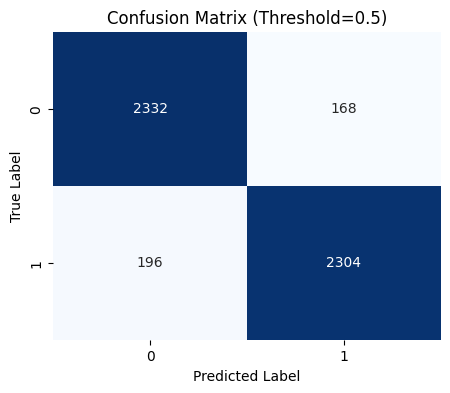

2071

In [8]:
y_pred = clf.predict(X_val_pairs)
y_prob = clf.predict_proba(X_val_pairs)[:,1]


def evaluate_threshold(y_true, y_prob, thr):
    y_pred_thr = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_thr).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"Threshold: {thr:.4f}")
    print(f"True Negatives: {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives: {tp}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(classification_report(y_true, y_pred_thr, digits=4))
    
    # Plot confusion matrix
    cm = np.array([[tn, fp], [fn, tp]])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix (Threshold={thr})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Set threshold manually
manual_thr = 0.5 # change this value to test different thresholds
evaluate_threshold(y_val_pairs, y_prob, manual_thr)

del X_val_pairs, y_val_pairs
gc.collect()

## Saving the Models

In [9]:
embedding_model.save("embedding_model.keras")
joblib.dump(clf, "signature_classifier.pkl")
joblib.dump(signature_data, "signature_data.pkl")



['signature_data.pkl']

Generating pairwise data for classifier...
Training LogisticRegression...
Threshold: 0.7000
True Negatives: 2519
False Positives: 981
False Negatives: 203
True Positives: 1297
Recall: 0.8647
Precision: 0.5694
              precision    recall  f1-score   support

           0     0.9254    0.7197    0.8097      3500
           1     0.5694    0.8647    0.6866      1500

    accuracy                         0.7632      5000
   macro avg     0.7474    0.7922    0.7482      5000
weighted avg     0.8186    0.7632    0.7728      5000



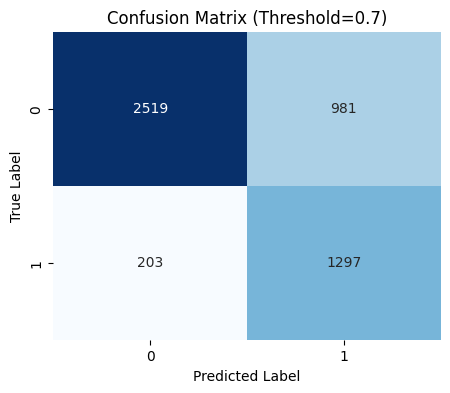

In [10]:
print("Generating pairwise data for classifier...")
X_train_pairs, y_train_pairs = generate_pairs_for_classifier_safe(signature_data, train_ids, embedding_model, num_pairs=NUM_PAIRS_FOR_CLASSIFIER, forged_ratio=0.7)
X_val_pairs, y_val_pairs = generate_pairs_for_classifier_safe(signature_data, val_ids, embedding_model, num_pairs=int(NUM_PAIRS_FOR_CLASSIFIER*0.5), forged_ratio=0.7)

print("Training LogisticRegression...")
clf = LogisticRegression(max_iter=2000, solver='saga', n_jobs=-1)
clf.fit(X_train_pairs, y_train_pairs)
# Set threshold manually
manual_thr = 0.7 # change this value to test different thresholds
evaluate_threshold(y_val_pairs, y_prob, manual_thr)

In [11]:
def preprocess_signature(img: np.ndarray, final_size=(224, 224)) -> np.ndarray:
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    processed = img.copy()
    processed[binary == 0] = 255
    processed = 255 - processed

    M = cv2.moments(binary)
    h, w = processed.shape
    cX = int(M["m10"] / M["m00"]) if M["m00"] != 0 else w // 2
    cY = int(M["m01"] / M["m00"]) if M["m00"] != 0 else h // 2
    tx, ty = w // 2 - cX, h // 2 - cY
    matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    centered = cv2.warpAffine(processed, matrix, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    resized = cv2.resize(centered, (242, 170))
    cropped = resized[10:-10, 11:-11]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(cropped)
    denoised = cv2.fastNlMeansDenoising(enhanced, None, 7, 7, 21)
    normalized = denoised.astype(np.float32) / 255.0
    final = cv2.resize(normalized, final_size)
    return np.expand_dims(final, axis=-1)

def preprocess_for_mobilenet(img_np, target_size=(224,224)):
    img = np.array(img_np, dtype=np.float32)
    if img.ndim == 2:
        img = np.expand_dims(img, -1)
    if img.max() <= 1.0:
        img = (img * 255.0).astype(np.float32)
    resized = cv2.resize(img[:,:,0], target_size).astype(np.float32)
    rgb = np.stack([resized, resized, resized], axis=-1)
    return preprocess_input(rgb)
def get_embedding(img_path):
    img = cv2.imread(img_path)
    img_pp = preprocess_signature(img)
    img_mb = preprocess_for_mobilenet(img_pp)
    emb = embedding_model.predict(img_mb[None, ...], verbose=0)[0]
    return emb

def verify_signature(reference_path, test_path, threshold=0.5):
    emb_ref = get_embedding(reference_path)
    emb_test = get_embedding(test_path)
    feat = np.abs(emb_ref - emb_test).reshape(1, -1)
    prob = clf.predict_proba(feat)[0,1]
    is_genuine = prob >= threshold
    return is_genuine, prob


In [12]:
my_genuine = "/kaggle/input/hasaan-signatures/hasaan_real.jpg"
forged = "/kaggle/input/hasaan-signatures/hasaan_forged.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Genuine: {result_genuine}, Prob={prob_genuine:.4f}")
print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/real-forged-signatures/Abdullah_real.jpg"
forged = "/kaggle/input/real-forged-signatures/Abdullah_forged.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/hasaan-signatures/hasaan_real.jpg"
forged = "/kaggle/input/real-forged-signatures/Hasaan_forged2.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/real-forged-signatures/Azhan_real.jpg"
forged = "/kaggle/input/real-forged-signatures/Azhan_forged.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/real-forged-signatures/Azhan_real.jpg"
forged = "/kaggle/input/real-forged-signatures/Azhan_forged2.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/real-forged-signatures/Azhan_real.jpg"
forged = "/kaggle/input/real-forged-signatures/Azhan_forged3.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/real-forged-signatures/Haniya_real.jpg"
forged = "//kaggle/input/real-forged-signatures/Haniya_forged.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/real-forged-signatures/Taha_real.jpg"
forged = "//kaggle/input/real-forged-signatures/Taha_forged.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")
my_genuine = "/kaggle/input/real-forged-signatures/Taha_real.jpg"
forged = "//kaggle/input/real-forged-signatures/Taha_forged1.jpg"

result_genuine, prob_genuine = verify_signature(my_genuine, my_genuine)
result_forged, prob_forged = verify_signature(my_genuine, forged)

print(f"Genuine vs Forged: {result_forged}, Prob={prob_forged:.4f}")


Genuine vs Genuine: True, Prob=0.9800
Genuine vs Forged: True, Prob=0.8597
Genuine vs Forged: True, Prob=0.8870
Genuine vs Forged: False, Prob=0.4121
Genuine vs Forged: False, Prob=0.0058
Genuine vs Forged: False, Prob=0.0071
Genuine vs Forged: True, Prob=0.9507
Genuine vs Forged: True, Prob=0.7024
Genuine vs Forged: False, Prob=0.3358
Genuine vs Forged: True, Prob=0.7665
